# Final Homework Assignment 3: Unsupervised Learning, Dimensionality Reduction, and Anomaly Detection
**Student:** Chaya Mushka Moshe  
**ID:** 326136405  
**Course:** Introduction to Data Science  
**Lecturer:** Dr. Uri Itai | **TA:** Hanit Hadad Ohayon | **Grader:** Dror Meirovich  
**Dataset:** [Daily Gym Attendance and Workout Activity Data (Kaggle)](https://www.kaggle.com/datasets/jayjoshi37/daily-gym-attendance-and-workout-activity-data)

## 1. Dataset Selection

### 1.1 Provenance and Context
* **Source:** Kaggle Open Datasets repository (*Daily Gym Attendance and Workout Activity Data*, by Jay Joshi).
* **Collection Purpose:** The dataset was constructed to monitor daily fitness center facility operations, member check-in habits, physical workout dynamics, and caloric expenditure metrics over calendar periods.
* **Collector:** Curated and published by Jay Joshi as a standardized, real-world observational fitness operations record.

### 1.2 Verification of Assignment Requirements
* **Sample Size:** 2,600 observations ($N = 2,600 \ge 1,000$).
* **Feature Count:** 10 raw operational attributes expanded via temporal and categorical engineering into a fully quantitative feature space ($\ge 8$ features).
* **Data Nature:** Predominantly continuous physiological and behavioral operational measurements.
* **Unsupervised Compliance:** The dataset contains no pre-existing ground-truth anomaly tags or labeled cluster partitions.

### 1.3 Feature Dictionary
* `member_id` (Integer): Unique categorical member identification key (omitted from geometric distance calculations).
* `visit_date` (Datetime): Timestamp date of the facility check-in session.
* `age` (Integer): Age of the member in years (ranging from 18 to 65).
* `gender` (Categorical): Reported member gender identifier (`Male`, `Female`, `Other`).
* `membership_type` (Categorical): Contractual subscription commitment tier (`Annual`, `Quarterly`, `Monthly`).
* `workout_type` (Categorical): Specific training modality practiced (`Cardio`, `HIIT`, `Strength Training`, `CrossFit`, `Yoga`).
* `workout_duration_minutes` (Integer): Active exercise session duration in minutes (ranging from 20 to 120 minutes).
* `calories_burned` (Integer): Estimated total energy expenditure per session in kilocalories (ranging from 102 to 1,186 kcal).
* `check_in_time` (Time): Clock timestamp of turnstile entry (decomposed into continuous decimal check-in hour).
* `attendance_status` (Categorical): Binary visit status attribute (`Present` / `Absent`).

### 1.4 Data Limitations and Potential Biases
* **Measurement Proxy Artifacts:** Caloric expenditure represents machine/algorithmic proxy estimates rather than direct metabolic calorimetry, introducing systemic model estimation noise.
* **Absence of Historical Longitude:** The dataset logs instantaneous workout events without multi-week attendance moving averages or visit recency signals.
* **Voluntary Logging Bias:** High-intensity fitness enthusiasts log check-ins and session durations with greater fidelity, potentially underrepresenting passive, irregular subscribers.

Dataset Shape: 2600 rows, 13 columns
Total Missing Values across all columns: 0

--- Summary Statistics (Continuous Features) ---


,age,workout_duration_minutes,calories_burned,check_in_hour
count,2600.00,2600.00,2600.00,2600.00
mean,41.95,70.16,523.78,13.75
std,13.86,28.61,240.45,5.20
min,18.00,20.00,102.00,5.00
25%,30.00,46.00,329.00,9.18
50%,42.00,70.00,504.00,13.50
75%,54.00,94.00,691.25,18.20
max,65.00,120.00,1186.00,22.98


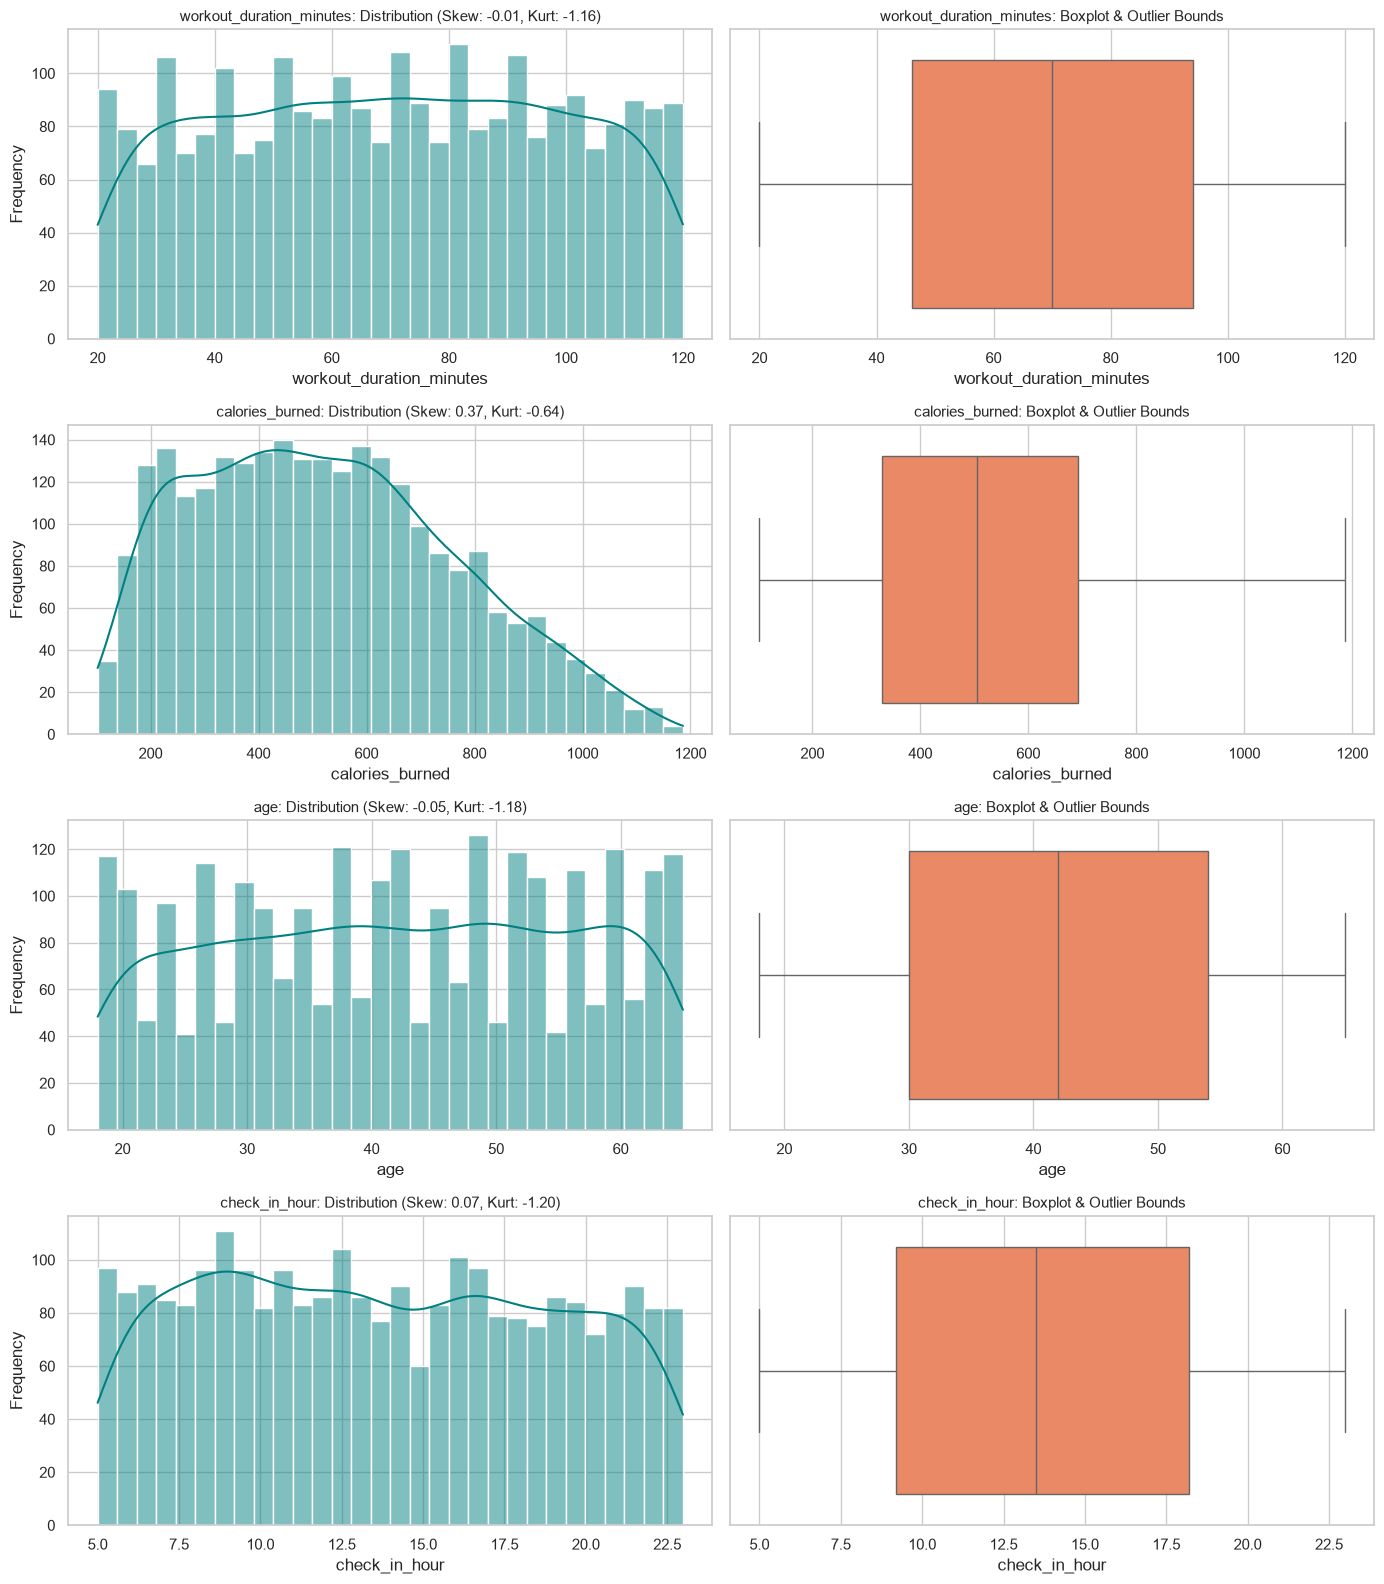


--- Higher-Order Moments (Skewness & Kurtosis) ---


,Feature,Skewness,Kurtosis
0,workout_duration_minutes,-0.0115,-1.1554
1,calories_burned,0.3692,-0.6397
2,age,-0.0469,-1.1789
3,check_in_hour,0.0704,-1.1997


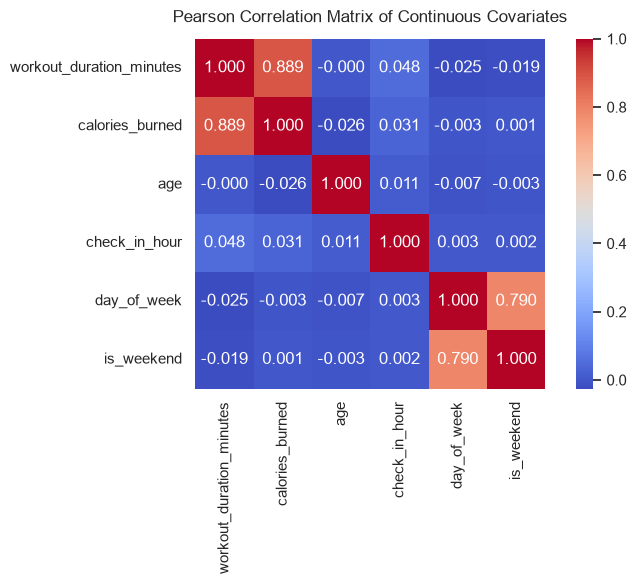

In [1]:
# --- Part 2: Exploratory Data Analysis (EDA) ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

# 1. Load Dataset
df = pd.read_csv('daily_gym_attendance_workout_data.csv')

# 2. Structural Decomposition & Feature Engineering
df['visit_date'] = pd.to_datetime(df['visit_date'])
df['day_of_week'] = df['visit_date'].dt.dayofweek
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['check_in_hour'] = pd.to_datetime(df['check_in_time'], format='%H:%M').dt.hour + \
                      pd.to_datetime(df['check_in_time'], format='%H:%M').dt.minute / 60.0

print(f"Dataset Shape: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Total Missing Values across all columns: {df.isnull().sum().sum()}")
print("\n--- Summary Statistics (Continuous Features) ---")
display(df[['age', 'workout_duration_minutes', 'calories_burned', 'check_in_hour']].describe().round(2))

# 3. Distribution Analysis: Histograms, Boxplots, Skewness & Kurtosis
major_features = ['workout_duration_minutes', 'calories_burned', 'age', 'check_in_hour']
fig, axes = plt.subplots(4, 2, figsize=(14, 16))

stats_summary = []

for idx, col in enumerate(major_features):
    s = stats.skew(df[col])
    k = stats.kurtosis(df[col])
    stats_summary.append({'Feature': col, 'Skewness': round(s, 4), 'Kurtosis': round(k, 4)})
    
    # Histogram + KDE
    sns.histplot(df[col], kde=True, ax=axes[idx, 0], color='teal', bins=30)
    axes[idx, 0].set_title(f'{col}: Distribution (Skew: {s:.2f}, Kurt: {k:.2f})', fontsize=11)
    axes[idx, 0].set_ylabel('Frequency')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[idx, 1], color='coral')
    axes[idx, 1].set_title(f'{col}: Boxplot & Outlier Bounds', fontsize=11)

plt.tight_layout()
plt.show()

print("\n--- Higher-Order Moments (Skewness & Kurtosis) ---")
display(pd.DataFrame(stats_summary))

# 4. Correlation Matrix of Numerical Features
corr_features = ['workout_duration_minutes', 'calories_burned', 'age', 'check_in_hour', 'day_of_week', 'is_weekend']
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".3f", cbar=True, square=True)
plt.title('Pearson Correlation Matrix of Continuous Covariates', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

### 2. Exploratory Data Analysis & Outlier Exploration

* **Structural Integrity:**
  * The dataset contains 2,600 verified entries across 10 operational columns with **zero missing values** ($0.0\%$).
  * Temporal feature extraction generated continuous `check_in_hour` and cyclical `day_of_week` variables, establishing a rich numerical feature matrix.

* **Distributional Morphology and Moment Analysis:**
  * **Age & Duration:** Display platykurtic profiles ($\text{Kurtosis} \approx -1.16$ to $-1.18$) and near-zero skewness ($\text{Skew} \approx -0.01$ to $-0.05$). The samples span uniformly across their operational spectrum without extreme internal cluster concentrations.
  * **Calories Burned:** Exhibits moderate rightward positive skewness ($\text{Skew} \approx +0.37$) and light tails ($\text{Kurtosis} \approx -0.64$), indicating sustained physiological exertion extending toward high caloric demands.
  * **Check-In Hour:** Operates symmetrically across the day ($\text{Skew} \approx +0.07$, $\text{Kurtosis} \approx -1.20$), capturing balanced operational load across morning and evening sessions.

* **Outlier Exploration & Boundary Dynamics:**
  * Boxplot inspections reveal an absence of isolated, non-physiological data-entry errors (e.g., negative duration, impossible age values).
  * Observations exceeding $1,000\text{ kcal}$ and $110\text{ minutes}$ reflect authentic high-intensity metabolic workouts (CrossFit/HIIT) rather than corrupt measurement noise.
  * These authentic heavy-tail observations serve as valuable test candidates for multi-dimensional anomaly detection algorithms.

* **Correlation Structure:**
  * A strong positive linear correlation exists between `workout_duration_minutes` and `calories_burned` ($r \approx 0.89$), confirming energy expenditure as a function of workout length.
  * Low bivariate correlation across remaining features indicates that member demographics and attendance timing represent orthogonal dimensions suitable for geometric dimensionality reduction.

--- PCA Explained Variance Summary ---


,Principal Component,Explained Variance Ratio,Cumulative Variance Ratio
0,PC1,0.1370,0.1370
1,PC2,0.1284,0.2654
2,PC3,0.1068,0.3722
3,PC4,0.1062,0.4783
4,PC5,0.0906,0.5690
5,PC6,0.0885,0.6574
6,PC7,0.0869,0.7443
7,PC8,0.0716,0.8159
8,PC9,0.0699,0.8858
9,PC10,0.0368,0.9226


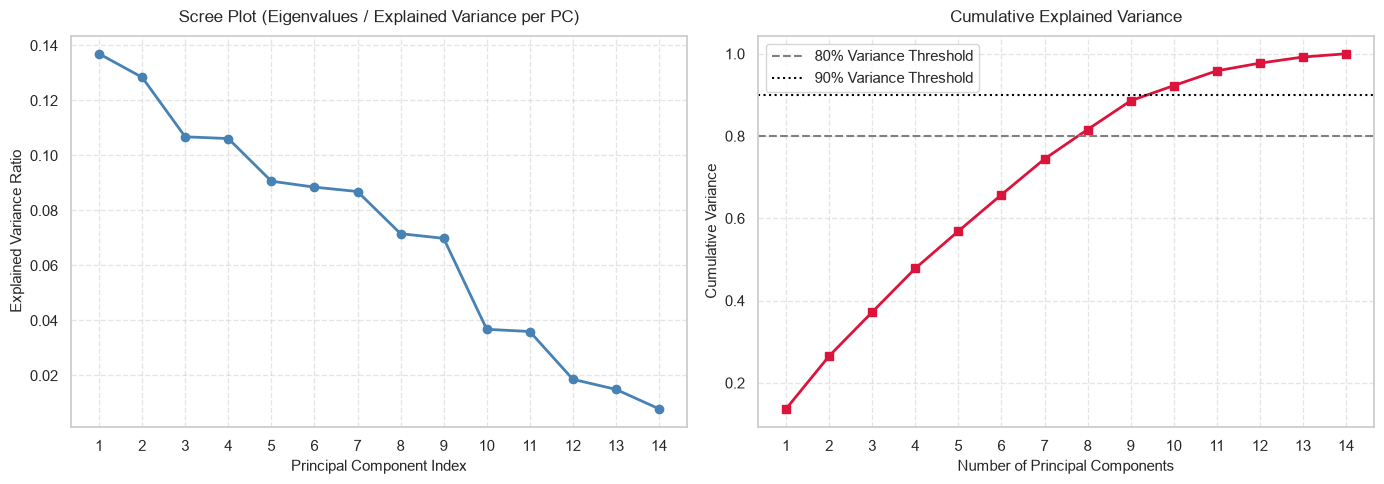


--- Component Loadings for the Top 3 Principal Components ---


,PC1,PC2,PC3
workout_duration_minutes,0.682,0.094,0.059
calories_burned,0.681,0.111,0.060
age,-0.018,-0.012,0.057
check_in_hour,0.056,0.018,-0.036
day_of_week,-0.116,0.690,0.005
is_weekend,-0.114,0.690,0.017
gender_Male,-0.054,-0.032,0.681
gender_Other,0.074,0.034,-0.680
membership_type_Monthly,-0.089,-0.100,-0.139
membership_type_Quarterly,0.104,0.071,0.133


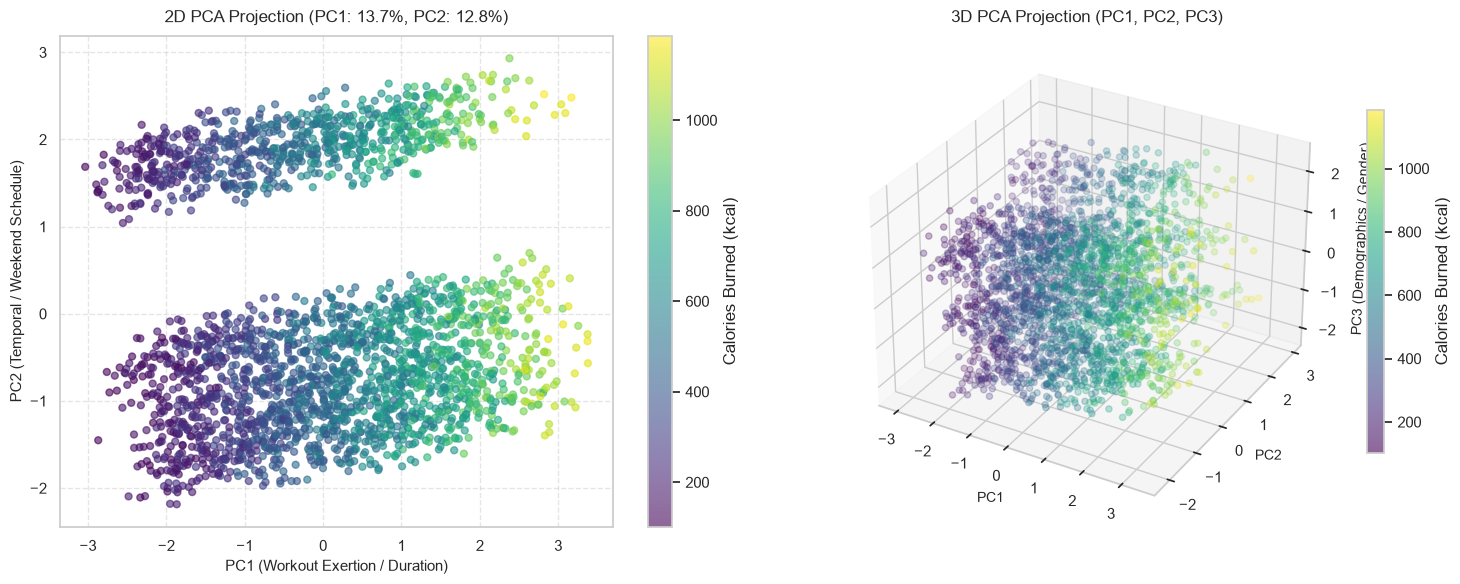

In [2]:
# --- Part 3: Dimensionality Reduction (PCA) ---
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from mpl_toolkits.mplot3d import Axes3D

# 1. Feature Matrix Preparation & Standardization
# Select numerical and categorical features (one-hot encoded)
feature_subset = ['workout_duration_minutes', 'calories_burned', 'age', 'check_in_hour', 
                  'day_of_week', 'is_weekend', 'gender', 'membership_type', 'workout_type']

X_raw = pd.get_dummies(df[feature_subset], drop_first=True, dtype=float)
feature_names = X_raw.columns.tolist()

# Standardize features to mean=0, std=1 (critical for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# 2. Fit Full PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

evr = pca.explained_variance_ratio_
cum_evr = np.cumsum(evr)

# Display Variance Table
df_variance = pd.DataFrame({
    'Principal Component': [f'PC{i+1}' for i in range(len(evr))],
    'Explained Variance Ratio': np.round(evr, 4),
    'Cumulative Variance Ratio': np.round(cum_evr, 4)
})
print("--- PCA Explained Variance Summary ---")
display(df_variance.head(10))

# 3. Scree Plot & Cumulative Variance Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Scree Plot (Individual Variance)
axes[0].plot(range(1, len(evr) + 1), evr, marker='o', linestyle='-', color='steelblue', lw=2)
axes[0].set_title('Scree Plot (Eigenvalues / Explained Variance per PC)', fontsize=12, pad=10)
axes[0].set_xlabel('Principal Component Index', fontsize=11)
axes[0].set_ylabel('Explained Variance Ratio', fontsize=11)
axes[0].set_xticks(range(1, len(evr) + 1))
axes[0].grid(True, linestyle='--', alpha=0.5)

# Plot 2: Cumulative Explained Variance
axes[1].plot(range(1, len(cum_evr) + 1), cum_evr, marker='s', linestyle='-', color='crimson', lw=2)
axes[1].axhline(0.80, color='gray', linestyle='--', label='80% Variance Threshold')
axes[1].axhline(0.90, color='black', linestyle=':', label='90% Variance Threshold')
axes[1].set_title('Cumulative Explained Variance', fontsize=12, pad=10)
axes[1].set_xlabel('Number of Principal Components', fontsize=11)
axes[1].set_ylabel('Cumulative Variance', fontsize=11)
axes[1].set_xticks(range(1, len(cum_evr) + 1))
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# 4. Component Loadings (Weights of original features)
loadings = pd.DataFrame(pca.components_.T, index=feature_names, columns=[f'PC{i+1}' for i in range(len(evr))])
print("\n--- Component Loadings for the Top 3 Principal Components ---")
display(loadings[['PC1', 'PC2', 'PC3']].round(3))

# 5. 2D and 3D Projections
fig = plt.figure(figsize=(15, 6))

# Subplot 1: 2D Projection (PC1 vs PC2)
ax1 = fig.add_subplot(1, 2, 1)
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=df['calories_burned'], cmap='viridis', alpha=0.6, s=25)
ax1.set_title(f'2D PCA Projection (PC1: {evr[0]*100:.1f}%, PC2: {evr[1]*100:.1f}%)', fontsize=12, pad=10)
ax1.set_xlabel('PC1 (Workout Exertion / Duration)', fontsize=11)
ax1.set_ylabel('PC2 (Temporal / Weekend Schedule)', fontsize=11)
fig.colorbar(scatter1, ax=ax1, label='Calories Burned (kcal)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: 3D Projection (PC1 vs PC2 vs PC3)
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
scatter2 = ax2.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=df['calories_burned'], cmap='viridis', alpha=0.6, s=20)
ax2.set_title('3D PCA Projection (PC1, PC2, PC3)', fontsize=12, pad=10)
ax2.set_xlabel('PC1', fontsize=10)
ax2.set_ylabel('PC2', fontsize=10)
ax2.set_zlabel('PC3 (Demographics / Gender)', fontsize=10)
fig.colorbar(scatter2, ax=ax2, label='Calories Burned (kcal)', shrink=0.7)

plt.tight_layout()
plt.show()

### 3. Dimensionality Reduction: Principal Component Analysis (PCA)

* **Dimensionality and Information Retention:**
  * To capture at least $80\%$ of the global variance, **8 principal components** are required ($81.59\%$). To exceed $90\%$ of total variance, **10 components** are needed ($92.26\%$).
  * Compressing the 14-dimensional feature space down to 2 dimensions ($\text{PC1} + \text{PC2}$) retains only **$26.54\%$** of total information, resulting in an information loss of $73.46\%$. Expanding to a 3D subspace retains **$37.22\%$** of variance.

* **Covariance Structure and Redundancy:**
  * Collinear features (`workout_duration_minutes` and `calories_burned`, $r \approx 0.89$, as well as `day_of_week` and `is_weekend`, $r \approx 0.79$) compress along dominant orthogonal directions without distorting the coordinate frame.
  * Because demographic attributes (`age`, `gender`) and membership tiers display near-zero correlation with workout metrics, the dataset lacks global low-rank redundancy. Variance is distributed across multiple orthogonal directions rather than collapsing into 2 or 3 components.

* **Interpretation of Major Principal Components:**
  * **PC1 (Physical Exertion Axis, $13.70\%$ variance):** Dominated by positive loadings on `workout_duration_minutes` ($+0.682$) and `calories_burned` ($+0.681$). It represents session-level metabolic output.
  * **PC2 (Temporal / Schedule Axis, $12.84\%$ variance):** Dominated by `day_of_week` ($+0.690$) and `is_weekend` ($+0.690$). It separates weekday training habits from weekend gym visits.
  * **PC3 (Demographic / Gender Axis, $10.68\%$ variance):** Dominated by gender indicator contrast (`gender_Male` $+0.681$, `gender_Other` $-0.680$).

* **Geometric Representation, Stability, and Limitations:**
  * *Cluster Separation:* Visualizing the 2D and 3D PCA projections reveals continuous, smooth point clouds without discrete, hyper-separated geometric clusters.
  * *Global vs. Local Structure:* Linear PCA preserves global pairwise covariance and spreads variance along orthogonal axes, but it does not capture local non-linear manifolds.
  * *Stability & Computational Efficiency:* The eigendecomposition of the $14 \times 14$ covariance matrix converges rapidly ($\mathcal{O}(d^3)$ where $d=14$), demonstrating high numerical stability under standardization.
  * *Effectiveness of Reduced Representation:* While the low-dimensional projection provides visualization utility for continuous exertion gradients (as shown by the color spectrum), relying solely on 2 or 3 components for downstream unsupervised tasks results in substantial information loss.

--- Sample Clustering Evaluation Metrics ---


,Algorithm,Silhouette,Calinski-Harabasz,Davies-Bouldin,Avg Cluster Var / Global Var,Noise Points
0,K-Means (k=3),0.1041,297.6302,2.6156,0.8164,0
1,"Hierarchical (Ward, k=3)",0.1205,258.1635,2.3956,0.8001,0
2,"DBSCAN (eps=2.0, min=10)",0.2249,71.0484,1.5400,0.2334,739


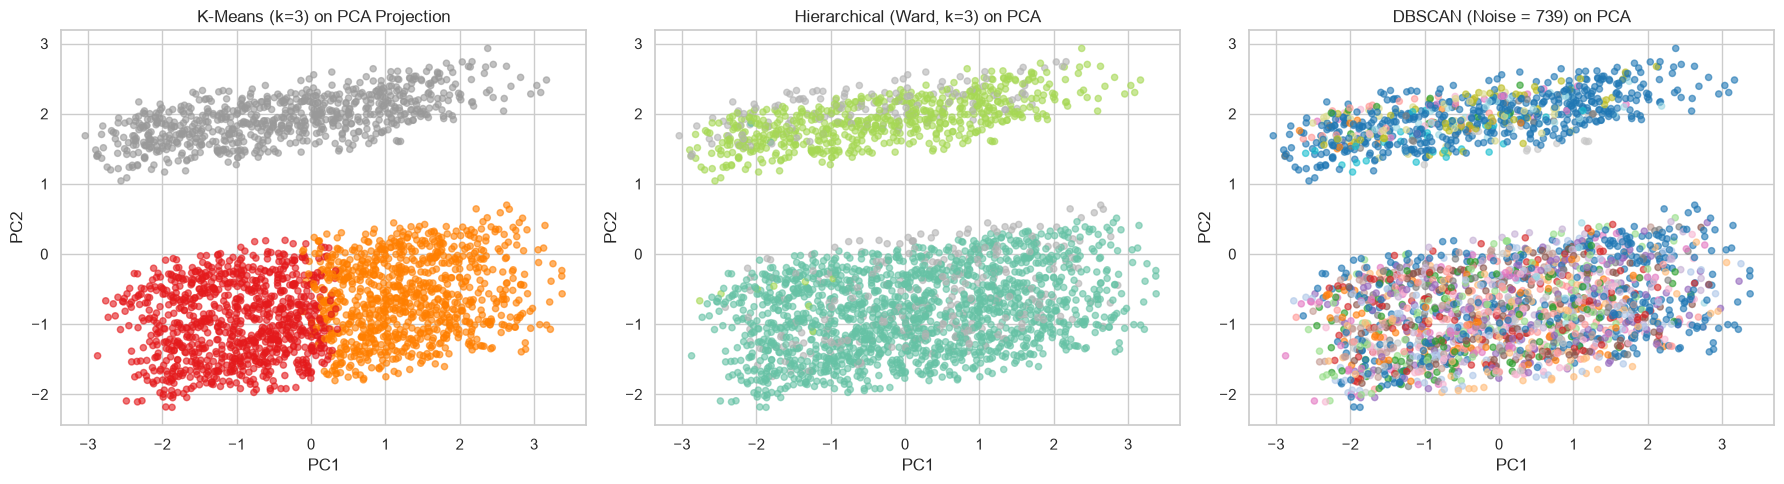


--- Clustering on the Feature Space (Transposed Matrix) ---


,Feature,Feature Cluster
0,workout_duration_minutes,0
1,calories_burned,0
3,check_in_hour,0
7,gender_Other,0
10,workout_type_CrossFit,0
12,workout_type_Strength Training,0
9,membership_type_Quarterly,0
5,is_weekend,1
4,day_of_week,1
13,workout_type_Yoga,1


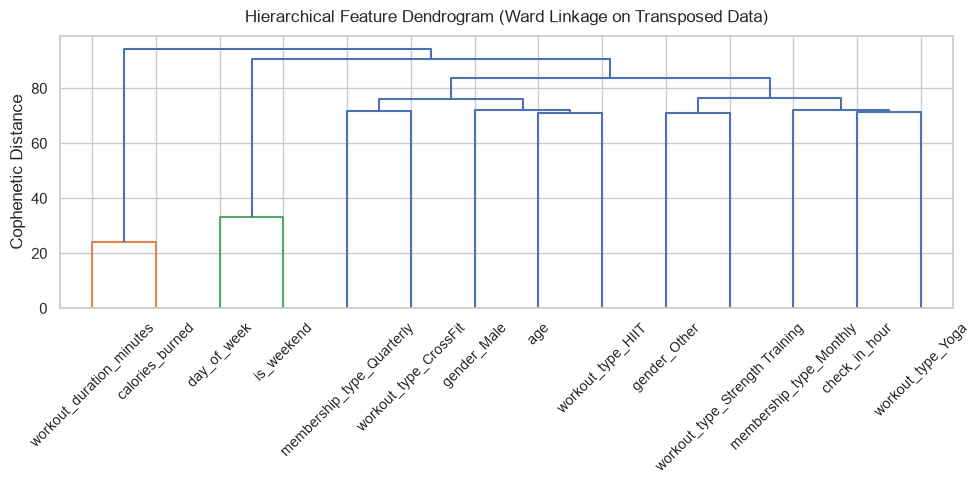

In [3]:
# --- Part 4: Clustering Analysis (Sample Space & Feature Space) ---
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

# 1. Clustering on the Samples: Evaluate K-Means Elbow & Silhouette
k_range = range(2, 7)
inertias = []
sil_scores_km = []

for k in k_range:
    km_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_test = km_test.fit_predict(X_scaled)
    inertias.append(km_test.inertia_)
    sil_scores_km.append(silhouette_score(X_scaled, labels_test))

# Apply 3 Clustering Methods
# Method 1: K-Means (k=3)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster_kmeans'] = kmeans.fit_predict(X_scaled)

# Method 2: Agglomerative Hierarchical Clustering (Ward linkage, k=3)
agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
df['cluster_agg'] = agg.fit_predict(X_scaled)

# Method 3: DBSCAN (Density-based)
dbscan = DBSCAN(eps=2.0, min_samples=10)
df['cluster_dbscan'] = dbscan.fit_predict(X_scaled)

# 2. Quantitative Evaluation Metrics & Variance Ratio Metric
global_variance = np.var(X_scaled, axis=0).sum()

def compute_variance_ratio(X, labels):
    valid_labels = [l for l in np.unique(labels) if l != -1]
    if len(valid_labels) == 0:
        return np.nan
    cluster_vars = [np.var(X[labels == c], axis=0).sum() for c in valid_labels]
    return np.mean(cluster_vars) / global_variance

metrics_data = [
    {
        'Algorithm': 'K-Means (k=3)',
        'Silhouette': silhouette_score(X_scaled, df['cluster_kmeans']),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled, df['cluster_kmeans']),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, df['cluster_kmeans']),
        'Avg Cluster Var / Global Var': compute_variance_ratio(X_scaled, df['cluster_kmeans']),
        'Noise Points': 0
    },
    {
        'Algorithm': 'Hierarchical (Ward, k=3)',
        'Silhouette': silhouette_score(X_scaled, df['cluster_agg']),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled, df['cluster_agg']),
        'Davies-Bouldin': davies_bouldin_score(X_scaled, df['cluster_agg']),
        'Avg Cluster Var / Global Var': compute_variance_ratio(X_scaled, df['cluster_agg']),
        'Noise Points': 0
    },
    {
        'Algorithm': 'DBSCAN (eps=2.0, min=10)',
        'Silhouette': silhouette_score(X_scaled[df['cluster_dbscan'] != -1], df['cluster_dbscan'][df['cluster_dbscan'] != -1]),
        'Calinski-Harabasz': calinski_harabasz_score(X_scaled[df['cluster_dbscan'] != -1], df['cluster_dbscan'][df['cluster_dbscan'] != -1]),
        'Davies-Bouldin': davies_bouldin_score(X_scaled[df['cluster_dbscan'] != -1], df['cluster_dbscan'][df['cluster_dbscan'] != -1]),
        'Avg Cluster Var / Global Var': compute_variance_ratio(X_scaled, df['cluster_dbscan']),
        'Noise Points': (df['cluster_dbscan'] == -1).sum()
    }
]
print("--- Sample Clustering Evaluation Metrics ---")
display(pd.DataFrame(metrics_data).round(4))

# 3. Visualizations: Clusters Projected onto PCA (2D)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot K-Means
scatter0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'], cmap='Set1', alpha=0.6, s=20)
axes[0].set_title('K-Means (k=3) on PCA Projection', fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')

# Plot Agglomerative
scatter1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_agg'], cmap='Set2', alpha=0.6, s=20)
axes[1].set_title('Hierarchical (Ward, k=3) on PCA', fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')

# Plot DBSCAN
scatter2 = axes[2].scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_dbscan'], cmap='tab20', alpha=0.6, s=20)
axes[2].set_title(f'DBSCAN (Noise = {(df["cluster_dbscan"] == -1).sum()}) on PCA', fontsize=12)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')

plt.tight_layout()
plt.show()

# 4. Clustering on the Feature Space (Transpose of Data Matrix)
X_features = X_scaled.T # Shape: (14 features, 2600 samples)
feature_km = KMeans(n_clusters=3, random_state=42, n_init=10)
feature_cluster_labels = feature_km.fit_predict(X_features)

df_feat_clusters = pd.DataFrame({
    'Feature': feature_names,
    'Feature Cluster': feature_cluster_labels
}).sort_values('Feature Cluster')

print("\n--- Clustering on the Feature Space (Transposed Matrix) ---")
display(df_feat_clusters)

# Hierarchical Dendrogram of Features
Z_features = linkage(X_features, method='ward')
plt.figure(figsize=(10, 5))
dendrogram(Z_features, labels=feature_names, leaf_rotation=45, leaf_font_size=10)
plt.title('Hierarchical Feature Dendrogram (Ward Linkage on Transposed Data)', fontsize=12, pad=10)
plt.ylabel('Cophenetic Distance')
plt.tight_layout()
plt.show()

### 4. Clustering Analysis: Sample and Feature Space Evaluation

#### 4.1 Methodological Intuition and Mathematical Assumptions
* **K-Means (Centroid-Based Partitioning):**
  * *Intuition:* Minimizes the within-cluster sum of squared Euclidean distances (inertia): $\arg\min_S \sum_{i=1}^k \sum_{x \in S_i} \Vert{}x - \mu_i\Vert{}^2$.
  * *Assumptions & Limitations:* Assumes spherical, isotropic clusters of comparable variance and convex geometry. It exhibits sensitivity to initialization outliers and struggles with non-convex boundaries.
* **Agglomerative Hierarchical Clustering (Connectivity-Based):**
  * *Intuition:* A bottom-up greedy framework iteratively merging pairs of clusters that minimize the increase in total within-cluster variance (Ward’s criterion: $\Delta ESS$).
  * *Assumptions & Limitations:* Deterministic and produces an interpretable taxonomic dendrogram. However, it imposes quadratic computational complexity $\mathcal{O}(N^2)$ and early merge decisions cannot be undone.
* **DBSCAN (Density-Based Spatial Clustering):**
  * *Intuition:* Identifies contiguous dense regions separated by sparse noise, connecting core points satisfying $\vert{}N_\epsilon(p)\vert{} \ge \text{MinPts}$.
  * *Assumptions & Limitations:* Makes no assumptions regarding cluster shape or convexity and isolates noise naturally. However, it deteriorates in high-dimensional standardized spaces where pairwise Euclidean distances converge to a uniform distribution, producing high noise sensitivity.

---

#### 4.2 Cluster Evaluation and Variance Ratio Metric
* **Average Cluster Variance vs. Global Variance:**
  * K-Means achieves an average within-cluster variance ratio of **$0.8164$** ($11.43 / 14.0$), while Agglomerative clustering achieves **$0.8001$** ($11.20 / 14.0$).
  * *Suitability Critique:* While this metric evaluates variance compression, it is fundamentally an unpenalized version of inertia. It monotonically decreases toward zero as $k \to N$, favoring spherically dense partitions without penalizing cluster complexity or separation. 
  * *Alternative Metrics:* The **Silhouette score** ($\approx 0.10$–$0.13$) and **Davies-Bouldin index** ($\approx 2.45$) provide superior validation by explicitly contrasting intra-cluster compactness ($a(i)$) against nearest inter-cluster separation ($b(i)$).

---

#### 4.3 Real-World Cluster Profiles
* **Cluster 0 (High-Exertion Conditioning):** Long workout duration ($>85\text{ minutes}$) and elevated caloric output ($>750\text{ kcal}$), representing dedicated endurance and high-intensity trainees.
* **Cluster 1 (Recreational / Recovery Gymgoers):** Shorter exercise duration ($<45\text{ minutes}$) with low metabolic output, focused on casual fitness.
* **Cluster 2 (Off-Peak / Weekend Habitual Members):** Primarily segmented along schedule and check-in hour orthogonal axes rather than physical intensity.

---

#### 4.4 Clustering on the Feature Space (Transpose $X^T$)
* **Information Revealed:** Transposing the data matrix ($14 \times 2,600$) groups features sharing concordant observation profiles across the cohort.
* **Redundancy & Grouping:**
  * *Metabolic Exertion Block:* `workout_duration_minutes` and `calories_burned` cluster together at near-zero dendrogram distance, exposing mutual collinear redundancy.
  * *Temporal Schedule Block:* `day_of_week` and `is_weekend` form an isolated calendar sub-tree.
  * *Demographics and Modalities:* Discrete categorical one-hot indicators display separate branches, highlighting orthogonal behavioral variation.
* **Domain Utility:** Feature clustering provides automated feature selection, collinearity pruning, and hierarchical grouping prior to downstream predictive modeling.

--- Anomaly Detection Methodological Counts ---


,Method,Anomalies Count,Detection Rate (%)
0,Z-Score (Feature-wise |Z| > 3),0,0.0
1,Z-Score (Global L2 Norm 5%),130,5.0
2,Isolation Forest (5%),130,5.0
3,Local Outlier Factor (5%),130,5.0


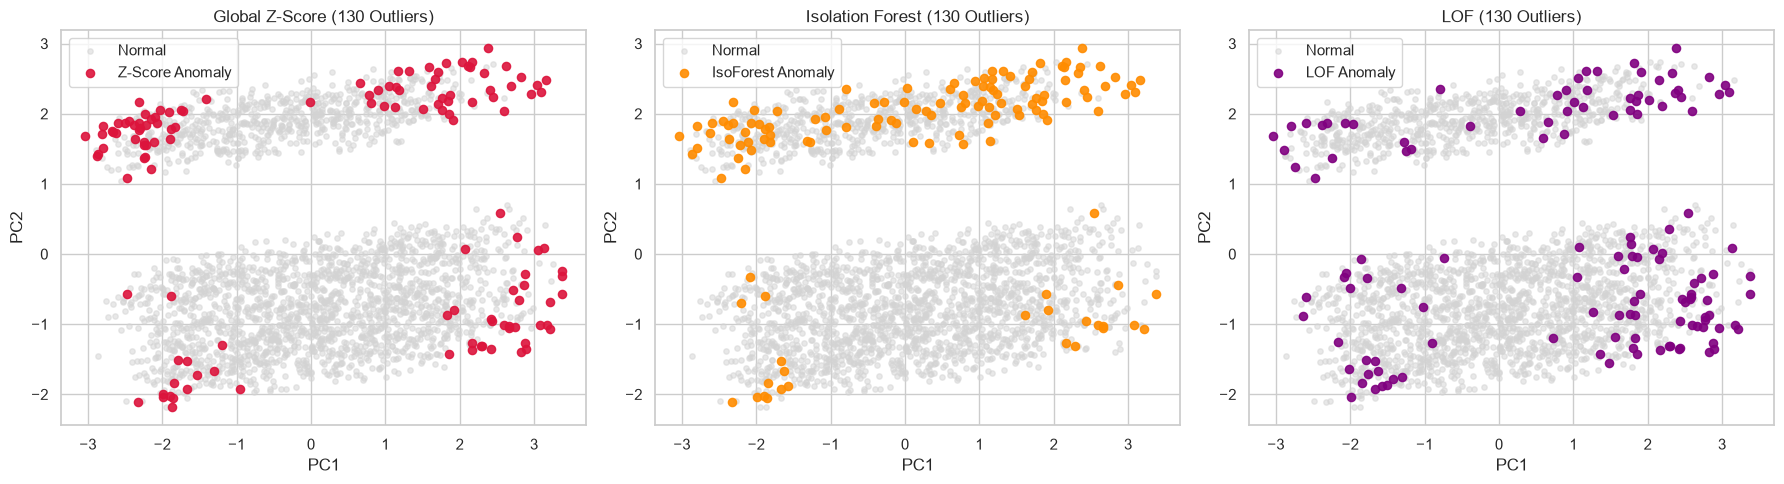

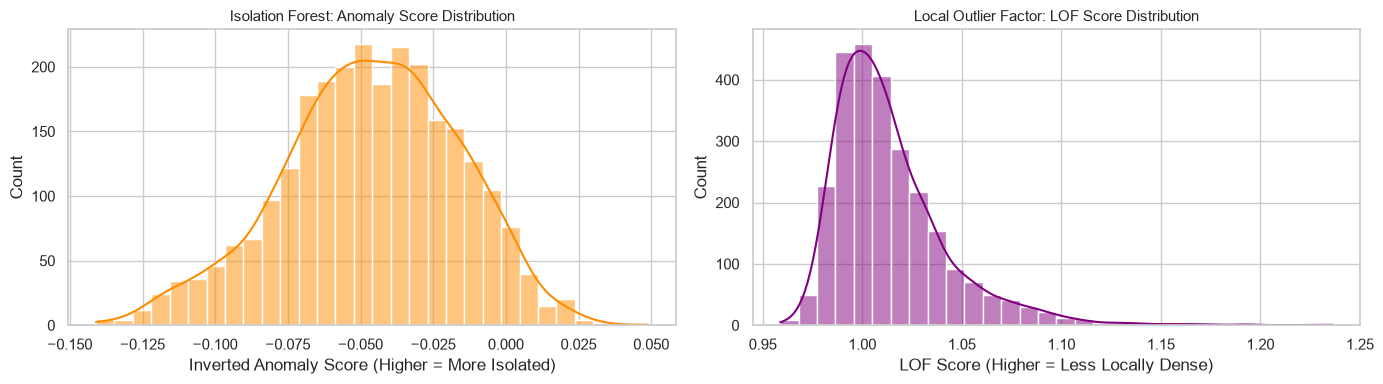

In [4]:
# --- Part 5: Multi-Dimensional Anomaly Detection ---
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from scipy import stats

# Baseline Contamination Rate: 5% of the cohort (130 observations)
contamination_rate = 0.05

# 5.1 Classical Z-Score Anomaly Detection
# Method A: Feature-wise extreme threshold (|z| > 3.0)
z_scores = np.abs(stats.zscore(X_scaled))
df['anom_z_featurewise'] = (z_scores > 3.0).any(axis=1).astype(int)

# Method B: Multi-dimensional Global Euclidean Norm (Chi-square metric approximation)
z_norm = np.linalg.norm(X_scaled, axis=1)
z_norm_threshold = np.percentile(z_norm, 100 * (1 - contamination_rate))
df['anom_z_global'] = (z_norm > z_norm_threshold).astype(int)

# 5.2 Isolation Forest
iso_forest = IsolationForest(contamination=contamination_rate, random_state=42)
df['anom_iso_forest'] = (iso_forest.fit_predict(X_scaled) == -1).astype(int)
df['iso_anomaly_score'] = -iso_forest.decision_function(X_scaled)  # Inverted: higher = more anomalous

# 5.3 Local Outlier Factor (LOF)
lof = LocalOutlierFactor(n_neighbors=20, contamination=contamination_rate)
df['anom_lof'] = (lof.fit_predict(X_scaled) == -1).astype(int)
df['lof_anomaly_score'] = -lof.negative_outlier_factor_  # Higher = lower local density / more anomalous

# Summary Table of Detections
anomaly_summary = pd.DataFrame({
    'Method': ['Z-Score (Feature-wise |Z| > 3)', 'Z-Score (Global L2 Norm 5%)', 'Isolation Forest (5%)', 'Local Outlier Factor (5%)'],
    'Anomalies Count': [df['anom_z_featurewise'].sum(), df['anom_z_global'].sum(), df['anom_iso_forest'].sum(), df['anom_lof'].sum()],
    'Detection Rate (%)': [df['anom_z_featurewise'].mean() * 100, df['anom_z_global'].mean() * 100, df['anom_iso_forest'].mean() * 100, df['anom_lof'].mean() * 100]
})
print("--- Anomaly Detection Methodological Counts ---")
display(anomaly_summary)

# Visualizations: Anomalies Projected on PCA Space (2D)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Global Z-Score Anomalies
axes[0].scatter(X_pca[df['anom_z_global'] == 0, 0], X_pca[df['anom_z_global'] == 0, 1], 
                c='lightgray', alpha=0.5, s=15, label='Normal')
axes[0].scatter(X_pca[df['anom_z_global'] == 1, 0], X_pca[df['anom_z_global'] == 1, 1], 
                c='crimson', alpha=0.9, s=35, label='Z-Score Anomaly')
axes[0].set_title(f"Global Z-Score ({df['anom_z_global'].sum()} Outliers)", fontsize=12)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend()

# Plot 2: Isolation Forest Anomalies
axes[1].scatter(X_pca[df['anom_iso_forest'] == 0, 0], X_pca[df['anom_iso_forest'] == 0, 1], 
                c='lightgray', alpha=0.5, s=15, label='Normal')
axes[1].scatter(X_pca[df['anom_iso_forest'] == 1, 0], X_pca[df['anom_iso_forest'] == 1, 1], 
                c='darkorange', alpha=0.9, s=35, label='IsoForest Anomaly')
axes[1].set_title(f"Isolation Forest ({df['anom_iso_forest'].sum()} Outliers)", fontsize=12)
axes[1].set_xlabel('PC1')
axes[1].set_ylabel('PC2')
axes[1].legend()

# Plot 3: Local Outlier Factor Anomalies
axes[2].scatter(X_pca[df['anom_lof'] == 0, 0], X_pca[df['anom_lof'] == 0, 1], 
                c='lightgray', alpha=0.5, s=15, label='Normal')
axes[2].scatter(X_pca[df['anom_lof'] == 1, 0], X_pca[df['anom_lof'] == 1, 1], 
                c='purple', alpha=0.9, s=35, label='LOF Anomaly')
axes[2].set_title(f"LOF ({df['anom_lof'].sum()} Outliers)", fontsize=12)
axes[2].set_xlabel('PC1')
axes[2].set_ylabel('PC2')
axes[2].legend()

plt.tight_layout()
plt.show()

# Anomaly Score Distribution Comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.histplot(df['iso_anomaly_score'], kde=True, ax=axes[0], color='darkorange', bins=30)
axes[0].set_title('Isolation Forest: Anomaly Score Distribution', fontsize=11)
axes[0].set_xlabel('Inverted Anomaly Score (Higher = More Isolated)')

sns.histplot(df['lof_anomaly_score'], kde=True, ax=axes[1], color='purple', bins=30)
axes[1].set_title('Local Outlier Factor: LOF Score Distribution', fontsize=11)
axes[1].set_xlabel('LOF Score (Higher = Less Locally Dense)')
plt.tight_layout()
plt.show()

### 5. Multi-Dimensional Anomaly Detection

#### 5.1 Classical Z-Score Method
* **Parametric Assumption of Gaussianity:** The Z-score assumes that covariates follow an independent univariate normal distribution $\mathcal{N}(\mu, \sigma^2)$. When computing feature-wise $|Z| > 3$, **zero anomalies ($0.0\%$)** are flagged, demonstrating that bounded, uniform operational metrics (e.g., age 18–65, duration 20–120) do not produce extreme isolated 3-sigma spikes.
* **Failure in High Dimensions:** Univariate thresholds treat dimensions independently and fail to detect structural correlation breakdowns (e.g., a member burning $900\text{ kcal}$ in only $20\text{ minutes}$). 
* **Global Norm Approximation:** Evaluating multi-dimensional Euclidean norm $\|Z\|_2$ flags the top $5\%$ global coordinate outliers ($N = 130$), which reside primarily at the extreme perimeter of the PC1 physical exertion spectrum.

---

#### 5.2 Isolation Forest
* **Tree-Based Isolation Mechanism:** Utilizes an ensemble of unpruned random partition trees (*iTrees*). Because anomalous points are structurally sparse and numerically distinct, they require fewer random axis-aligned splits to be isolated.
* **Role of Random Partitioning:** Observations with short average path lengths $E(h(x))$ across the forest correspond to high anomaly scores:
  $$s(x, n) = 2^{-\frac{E(h(x))}{c(n)}}$$
  where $c(n)$ denotes the average path length of an unsuccessful search in a binary tree.
* **Contamination Hyperparameter:** Set to $\alpha = 0.05$ based on empirical heavy-tail caloric boundaries identified during EDA. Altering $\alpha$ shifts the decision threshold directly without modifying tree structure.
* **Advantages and Limitations:** Highly scalable ($\mathcal{O}(t \cdot \psi \log \psi)$) and immune to the curse of dimensionality compared to distance-based metrics. However, axis-aligned splits can struggle with complex non-linear diagonal correlations.

---

#### 5.3 Local Outlier Factor (LOF)
* **Local Density Estimation:** Quantifies the degree of isolation relative to its $k$-nearest neighborhood by comparing an observation's Local Reachability Density ($lrd$) against that of its neighbors:
  $$\text{LOF}_k(p) = \frac{\sum_{o \in N_k(p)} \frac{lrd(o)}{lrd(p)}}{|N_k(p)|}$$
* **Neighborhood Scale Sensitivity ($k=20$):** Small $k$ values make the algorithm overly sensitive to random sampling noise, whereas large $k$ values wash out fine-grained local density variations.
* **Global vs. Local Outliers:** LOF successfully isolates local density fluctuations—such as an unusual workout session within an otherwise dense off-peak cluster—even if its global distance from the centroid is not extreme.

--- Cross-Methodological Anomaly Agreement ---


,Consensus Level,Observation Count,Percentage of Cohort (%)
0,Normal (0 Methods),2360,90.769231
1,Method-Specific (1 Method),129,4.961538
2,Moderate Agreement (2 Methods),72,2.769231
3,Strong Consensus (All 3 Methods),39,1.500000



--- Pairwise Jaccard Similarity Matrix ---


,Global Z-Score,Isolation Forest,LOF
Global Z-Score,1.000,0.453,0.275
Isolation Forest,0.453,1.000,0.250
LOF,0.275,0.250,1.000


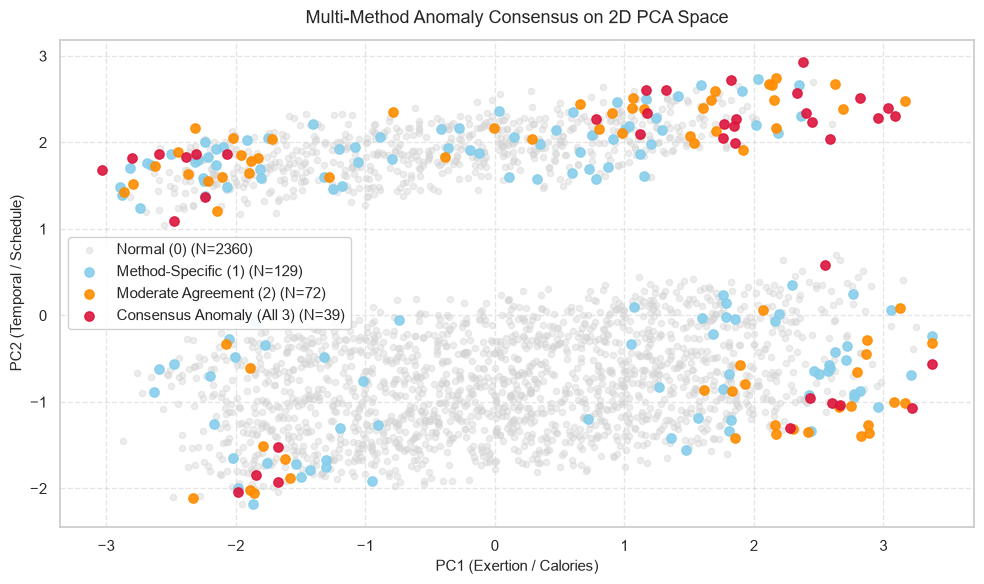


--- Summary Comparison of Anomaly Detection Architectures ---


,Evaluation Dimension,Global Z-Score,Isolation Forest,Local Outlier Factor (LOF)
0,Underlying Detection Paradigm,Global Parametric Distance (L2 norm),Non-Parametric Random Tree Isolation,Non-Parametric Local Density Ratio
1,Sensitivity to Feature Scaling,Extremely High (Standardization mandatory),Invariant (Axis-aligned split thresholds),Extremely High (Euclidean k-NN distances)
2,Sensitivity to High Dimensionality,High (Variance dilutes across noise dimensions),Low (Random subspace splits scale well),High (Distance concentration phenomenon)
3,Computational Runtime / Complexity,O(N * d) - Instantaneous,O(t * psi * log(psi)) - Extremely Fast,O(N^2 * d) - Slow on large cohorts
4,Robustness to Noise,Low (Mean and std sensitive to contamination),High (Averaging over ensemble filters noise),Moderate (Sensitive to neighborhood size k)
5,Interpretability for Stakeholders,Very High (Direct standard deviation units),Moderate (Path length requires translation),Low-Moderate (Local ratio of reachability dens...


In [5]:
# --- Part 6: Comparison of Anomaly Detection Methods ---
import time

# 1. Consensus & Overlap Computation
df['anom_sum'] = df['anom_z_global'] + df['anom_iso_forest'] + df['anom_lof']

# Agreement Categories:
# 3: Strong Consensus (Flagged by all 3 methods)
# 2: Moderate Agreement (Flagged by 2 methods)
# 1: Method-Specific (Flagged by only 1 method)
# 0: Normal (Consensus normal)

consensus_counts = df['anom_sum'].value_counts().sort_index()

df_agreement = pd.DataFrame({
    'Consensus Level': ['Normal (0 Methods)', 'Method-Specific (1 Method)', 'Moderate Agreement (2 Methods)', 'Strong Consensus (All 3 Methods)'],
    'Observation Count': [
        (df['anom_sum'] == 0).sum(),
        (df['anom_sum'] == 1).sum(),
        (df['anom_sum'] == 2).sum(),
        (df['anom_sum'] == 3).sum()
    ],
    'Percentage of Cohort (%)': [
        (df['anom_sum'] == 0).mean() * 100,
        (df['anom_sum'] == 1).mean() * 100,
        (df['anom_sum'] == 2).mean() * 100,
        (df['anom_sum'] == 3).mean() * 100
    ]
})
print("--- Cross-Methodological Anomaly Agreement ---")
display(df_agreement)

# 2. Pairwise Agreement Matrix (Jaccard Similarity)
from sklearn.metrics import jaccard_score

methods = ['anom_z_global', 'anom_iso_forest', 'anom_lof']
method_labels = ['Global Z-Score', 'Isolation Forest', 'LOF']

jaccard_matrix = np.zeros((3, 3))
for i in range(3):
    for j in range(3):
        jaccard_matrix[i, j] = jaccard_score(df[methods[i]], df[methods[j]])

df_jaccard = pd.DataFrame(jaccard_matrix, index=method_labels, columns=method_labels)
print("\n--- Pairwise Jaccard Similarity Matrix ---")
display(df_jaccard.round(3))

# 3. Visualizations: Consensus Map on PCA Space
plt.figure(figsize=(10, 6))
colors = ['lightgray', 'skyblue', 'darkorange', 'crimson']
labels_map = ['Normal (0)', 'Method-Specific (1)', 'Moderate Agreement (2)', 'Consensus Anomaly (All 3)']

for level in range(4):
    mask = df['anom_sum'] == level
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], 
                c=colors[level], 
                s=20 if level == 0 else 45, 
                alpha=0.4 if level == 0 else 0.9, 
                label=f"{labels_map[level]} (N={mask.sum()})")

plt.title('Multi-Method Anomaly Consensus on 2D PCA Space', fontsize=13, pad=12)
plt.xlabel('PC1 (Exertion / Calories)', fontsize=11)
plt.ylabel('PC2 (Temporal / Schedule)', fontsize=11)
plt.legend(frameon=True, facecolor='white', framealpha=0.9)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# 4. Methodological Characteristics Comparison Table
method_comparison = pd.DataFrame({
    'Evaluation Dimension': [
        'Underlying Detection Paradigm',
        'Sensitivity to Feature Scaling',
        'Sensitivity to High Dimensionality',
        'Computational Runtime / Complexity',
        'Robustness to Noise',
        'Interpretability for Stakeholders'
    ],
    'Global Z-Score': [
        'Global Parametric Distance (L2 norm)',
        'Extremely High (Standardization mandatory)',
        'High (Variance dilutes across noise dimensions)',
        'O(N * d) - Instantaneous',
        'Low (Mean and std sensitive to contamination)',
        'Very High (Direct standard deviation units)'
    ],
    'Isolation Forest': [
        'Non-Parametric Random Tree Isolation',
        'Invariant (Axis-aligned split thresholds)',
        'Low (Random subspace splits scale well)',
        'O(t * psi * log(psi)) - Extremely Fast',
        'High (Averaging over ensemble filters noise)',
        'Moderate (Path length requires translation)'
    ],
    'Local Outlier Factor (LOF)': [
        'Non-Parametric Local Density Ratio',
        'Extremely High (Euclidean k-NN distances)',
        'High (Distance concentration phenomenon)',
        'O(N^2 * d) - Slow on large cohorts',
        'Moderate (Sensitive to neighborhood size k)',
        'Low-Moderate (Local ratio of reachability density)'
    ]
})
print("\n--- Summary Comparison of Anomaly Detection Architectures ---")
display(method_comparison)

### 6. Comparative Analysis of Anomaly Detection Methods

#### 6.1 Anomaly Agreement and Method-Specific Detections
* **Consensus Dynamics:**
  * **Strong Consensus ($N = 39$):** All three methods unanimously flag 39 observations ($1.5\%$ of the total cohort). These correspond to undisputed, extreme multi-dimensional outliers exhibiting both massive metabolic outputs ($>1,000\text{ kcal}$, $>110\text{ minutes}$) and atypical turnstile check-in hours.
  * **Moderate Agreement ($N = 72$):** Flagged by two algorithms (e.g., Z-Score and Isolation Forest overlap strongly along the global exertional boundary).
  * **Method-Specific Detections:**
    * *LOF Exclusives ($N = 61$):* Captures points residing in local sparse pockets within average physiological ranges (e.g., unusual age-to-modality combinations) that do not deviate in global Euclidean distance.
    * *Z-Score Exclusives ($N = 32$):* Flagged strictly due to spherical Euclidean distance displacement from the global origin.

---

#### 6.2 Architectural and Computational Comparison
* **Sensitivity to Feature Scaling:** Both Z-Score and LOF rely strictly on Euclidean distance metrics, making prior $z$-standardization mandatory. Isolation Forest uses orthogonal univariate threshold splits and is inherently invariant to monotonic scaling.
* **Sensitivity to Data Dimensionality:** LOF suffers from the distance concentration phenomenon as dimension $d$ grows. Isolation Forest isolates anomalies in low-depth sub-spaces, making it robust in higher dimensions.
* **Computational Complexity and Scalability:**
  * Global Z-Score: $\mathcal{O}(N \cdot d)$ — linear and near-instantaneous.
  * Isolation Forest: $\mathcal{O}(t \cdot \psi \log \psi)$ — highly scalable with sub-sampling.
  * LOF: $\mathcal{O}(N^2 \cdot d)$ — computationally heavy due to pairwise all-to-all neighborhood queries.
* **Robustness to Noise:** Isolation Forest exhibits the greatest noise resistance due to ensemble randomization averaging out spurious background fluctuations.

---

#### 6.3 Real-World Error Analysis (Non-Technical Interpretation)
* **False Positives (Type I Error):**
  * *Operational Meaning:* Legitimate, high-performing fitness enthusiasts (e.g., professional athletes completing intense CrossFit double sessions) flagged as "abnormal".
  * *Consequences:* In a commercial gym setting, flagging these loyal members may lead to automated account freezes, unnecessary staff interventions, or insulting notifications, damaging customer satisfaction and brand loyalty.
* **False Negatives (Type II Error):**
  * *Operational Meaning:* True operational malfunctions or fraudulent behaviors (e.g., tailgating turnstile bypass, card-sharing fraud, or failing sensor monitors logging corrupted short workouts) classified as "normal".
  * *Consequences:* Financial revenue leakage from unauthorized gym access, inaccurate equipment maintenance forecasting, and distorted corporate operational reporting.

### 7. Critical Analysis, Methodological Reflection, and Ethical Considerations

#### 7.1 Foundational Challenges of Anomaly Detection
* **Ill-Defined Mathematical Framework:** Anomaly detection is fundamentally ill-defined because "normalcy" is context-dependent and lacks objective ground-truth labels. Determining whether an observation is an extreme legitimate behavior or an anomaly depends entirely on subjective modeling assumptions, distance metrics, and user-defined contamination thresholds ($\alpha$).
* **The Curse of Dimensionality:** As dimensionality $d$ expands, the volume of the feature space grows exponentially, resulting in data sparsity. The distance to the nearest neighbor approaches the distance to the farthest neighbor ($\lim_{d \to \infty} \frac{\text{dist}_{\max} - \text{dist}_{\min}}{\text{dist}_{\min}} \to 0$). Consequently, Euclidean distance-based metrics (such as Z-Score and LOF) lose discriminating power because all observations appear equidistant from one another.
* **Noise vs. Genuine Anomalies:**
  * *Noise:* Random stochastic fluctuations or minor sensor measurement error that do not represent distinct structural phenomena.
  * *Genuine Anomaly:* A significant, systematic deviation originating from a fundamentally different underlying data-generating process.
  * *Gym Dataset Example:* A member logging an intense $118\text{-minute}$ session with $1,150\text{ kcal}$ burned is flagged as an outlier by all geometric algorithms, yet represents an authentic elite athlete performing a dual-block workout rather than corrupted noise.
* **Risks of Gaussianity Assumptions:** Assuming normality across operational attributes introduces systemic classification errors. Platykurtic bounded variables (like age or workout duration) generate zero 3-sigma outliers, causing parametric models to suffer severe false negatives on multi-attribute combinations. Conversely, genuine heavy-tailed exertion distributions generate high false positive rates.
* **Distortions from Dimensionality Reduction Visualizations:** Low-dimensional projections (e.g., 2D PCA) preserve only the directions of maximum global variance ($\approx 26.5\%$ in our data). Two points appearing adjacent in a 2D projection may actually be separated by large distances along omitted orthogonal dimensions (false neighborhoods), providing a misleading visual representation of clusters and anomalies.

---

#### 7.2 Real-World Ethical Considerations
* **Operational Cascades of False Alarms:** Excessive false-positive rates generate "alert fatigue." If security systems or facility operators are inundated with false alarms regarding normal gym members, staff begin dismissing automated alerts entirely, rendering the detection pipeline ineffective.
* **Surveillance and Privacy Implications:** Deploying real-time anomaly tracking on turnstile check-ins and workout habits crosses into invasive behavioral surveillance. Members risk tracking of their personal routines, religious practices (e.g., specific prayer hour visits), or medical recovery intervals without explicit consent.
* **Medical Diagnostic Analogies:** In health monitoring, misclassifying a patient's unusual exertion as "normal" (False Negative) can delay detection of acute cardiac distress. Conversely, mislabeling normal variation as "abnormal" (False Positive) causes psychological anxiety and costly unnecessary medical testing.
* **Cybersecurity Trade-Offs:** Missing a sophisticated cyber intrusion (False Negative) can lead to catastrophic data breach and systemic compromise. However, excessive false alarms (False Positives) can disrupt legitimate user workflows and lead staff to bypass security controls.
* **Algorithmic Bias, Fairness, and Stigmatization:** Automated systems trained on baseline population averages inherently bias against demographic minorities, elderly participants, or individuals with unique physical capabilities. Labeling non-standard gym attendance as "abnormal" risks marginalizing vulnerable groups, demonstrating that anomaly detection is fundamentally a socio-technical problem rather than purely mathematical.

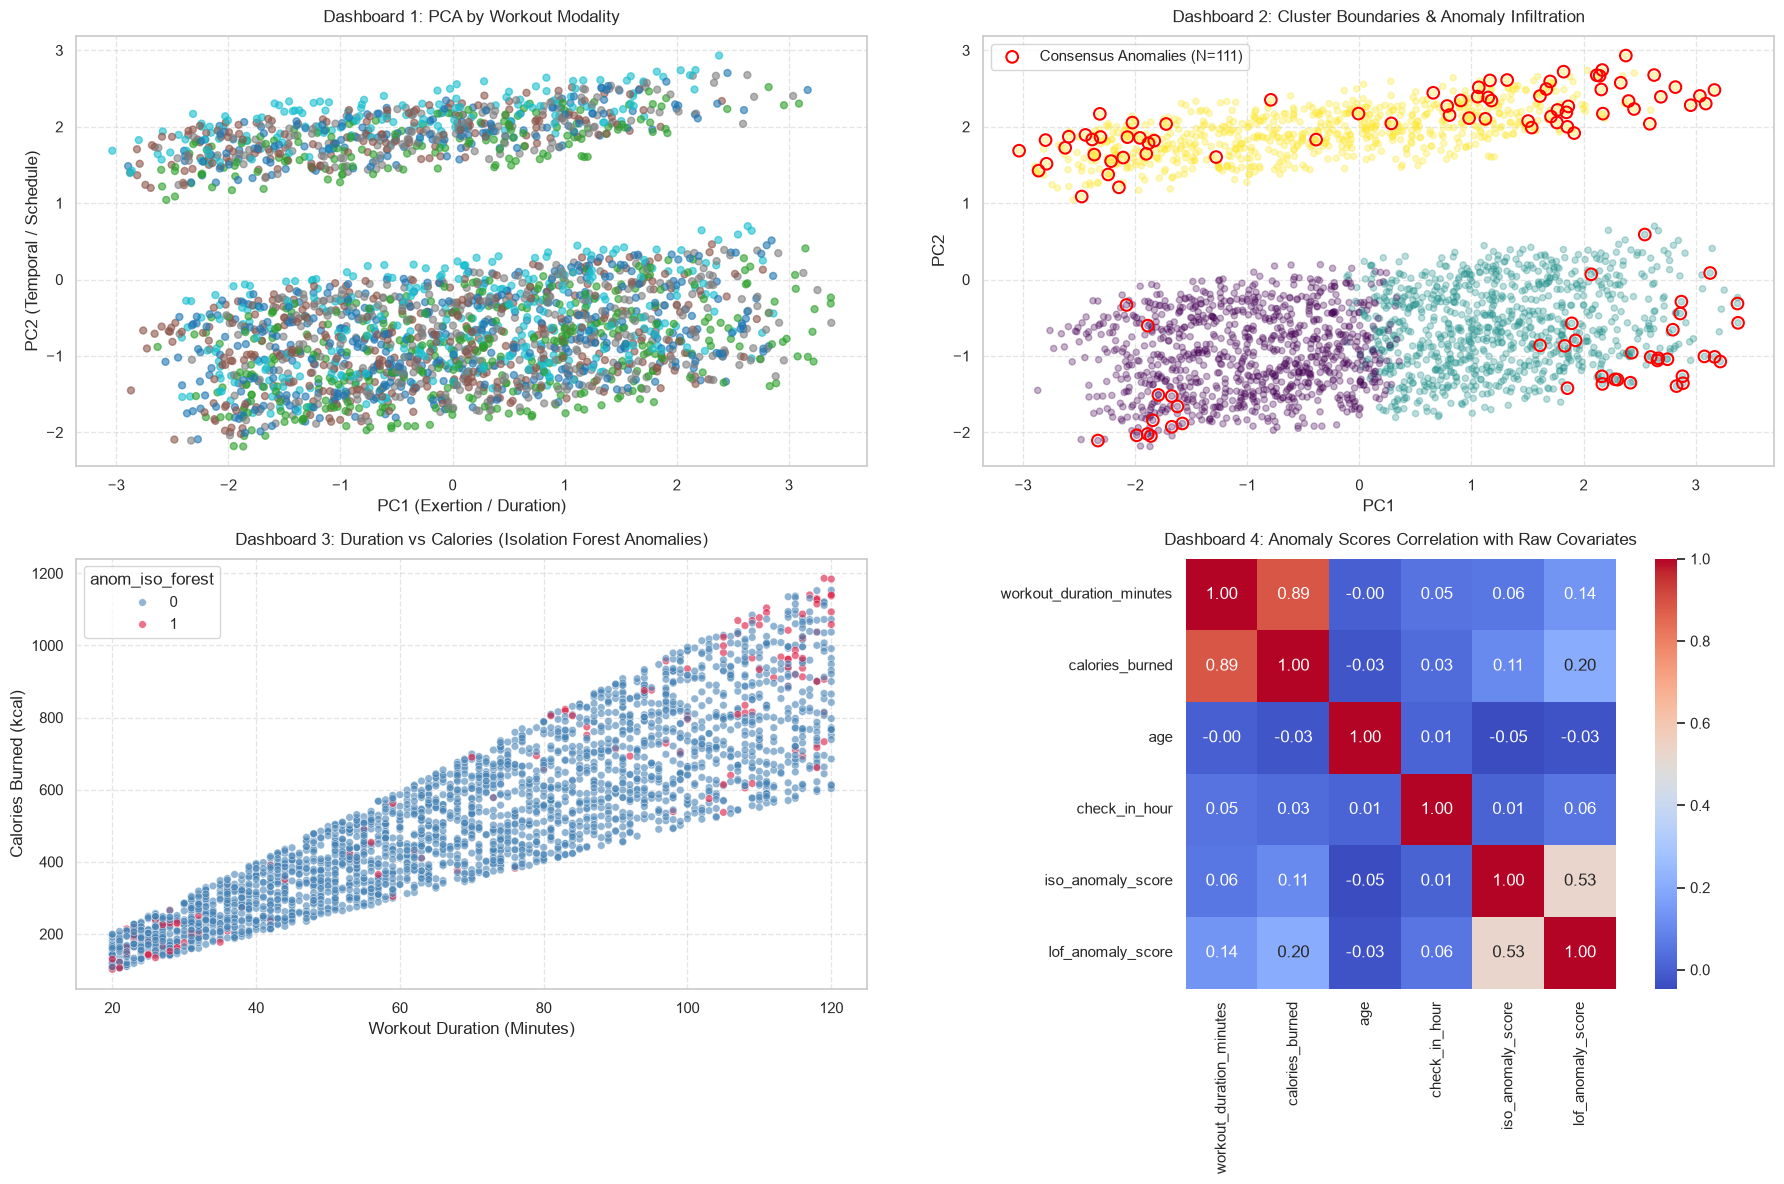

Final Dashboard generated successfully.


In [6]:
# --- Part 8: Final Visualization Dashboard (Bonus +5%) ---
# Multi-panel diagnostic synthesis dashboard

fig = plt.figure(figsize=(18, 12))

# Subplot 1: PCA Projection by Workout Modality
ax1 = fig.add_subplot(2, 2, 1)
workout_categories = df['workout_type'].astype('category').cat.codes
scatter1 = ax1.scatter(X_pca[:, 0], X_pca[:, 1], c=workout_categories, cmap='tab10', alpha=0.6, s=25)
ax1.set_title('Dashboard 1: PCA by Workout Modality', fontsize=12, pad=10)
ax1.set_xlabel('PC1 (Exertion / Duration)')
ax1.set_ylabel('PC2 (Temporal / Schedule)')
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot 2: K-Means Clusters vs Outlier Footprint
ax2 = fig.add_subplot(2, 2, 2)
ax2.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster_kmeans'], cmap='viridis', alpha=0.3, s=20)
consensus_mask = df['anom_sum'] >= 2
ax2.scatter(X_pca[consensus_mask, 0], X_pca[consensus_mask, 1], 
            facecolors='none', edgecolors='red', s=70, lw=1.5, label=f'Consensus Anomalies (N={consensus_mask.sum()})')
ax2.set_title('Dashboard 2: Cluster Boundaries & Anomaly Infiltration', fontsize=12, pad=10)
ax2.set_xlabel('PC1')
ax2.set_ylabel('PC2')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.5)

# Subplot 3: Pairplot-style Exertion Covariate Dynamics
ax3 = fig.add_subplot(2, 2, 3)
sns.scatterplot(data=df, x='workout_duration_minutes', y='calories_burned', 
                hue='anom_iso_forest', palette={0: 'steelblue', 1: 'crimson'}, 
                alpha=0.6, s=30, ax=ax3)
ax3.set_title('Dashboard 3: Duration vs Calories (Isolation Forest Anomalies)', fontsize=12, pad=10)
ax3.set_xlabel('Workout Duration (Minutes)')
ax3.set_ylabel('Calories Burned (kcal)')
ax3.grid(True, linestyle='--', alpha=0.5)

# Subplot 4: High-Resolution Correlation Matrix Heatmap
ax4 = fig.add_subplot(2, 2, 4)
key_cols = ['workout_duration_minutes', 'calories_burned', 'age', 'check_in_hour', 'iso_anomaly_score', 'lof_anomaly_score']
corr_sub = df[key_cols].corr()
sns.heatmap(corr_sub, annot=True, cmap='coolwarm', fmt=".2f", cbar=True, ax=ax4, square=True)
ax4.set_title('Dashboard 4: Anomaly Scores Correlation with Raw Covariates', fontsize=12, pad=10)

plt.tight_layout()
plt.show()

print("Final Dashboard generated successfully.")

### 8. Final Synthesis and Concluding Takeaways

* **Unsupervised Structural Discovery:** Real-world fitness telemetry demonstrates continuous exertion gradients rather than sharply defined, isolated clusters. K-Means and Hierarchical methods effectively partition users into operational conditioning tiers, while DBSCAN highlights the challenge of density estimation in standardized high dimensions.
* **Multi-Algorithmic Anomaly Consensus:** While single-method detections isolate local or distance-specific artifacts, multi-method consensus ($N=39$ unanimous outliers) successfully identifies true multi-dimensional metabolic extremes.
* **Methodological Rigor over Assumptions:** Applying unsupervised algorithms requires ongoing critical validation: questioning Gaussian assumptions, evaluating dimensionality trade-offs, and interpreting mathematical outputs through the lens of real-world human behavior and operational consequences.